
# Section 3 a - Create Quantum Circuits (Construct circuits)

## Certification weight: 18%

## Objectives 
- Construct dynamic circuits
- Construct parameterized circuits
- Transpile and optimize circuits
- Construct basic quantum circuits

## Quantum circuit

A quantum circuit is composed of quantum registers and classic registers

Create a simple circuit:

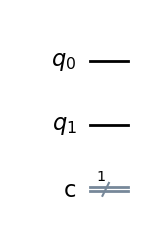

In [3]:
from qiskit.circuit import QuantumCircuit

qc = QuantumCircuit(2,1, name="My First Circuit")    #Two qubits and one classical bit

qc.draw("mpl")

In [4]:
qc.qregs

[QuantumRegister(2, 'q')]

In [7]:
qc.qubits

[<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>]

Create a circuit from registers

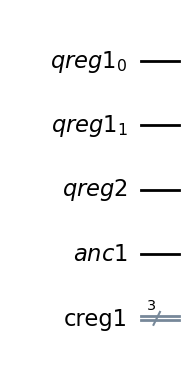

In [5]:
from qiskit.circuit import ClassicalRegister, QuantumRegister, AncillaRegister

qr1 = QuantumRegister(2, "qreg1")    # Create a QuantumRegister with 2 qubits
qr2 = QuantumRegister(1, "qreg2")    # Create a QuantumRegister with 1 qubit
ar1 = AncillaRegister(1, "anc1")     # Create an AncillaRegister with 1 qubit
cr1 = ClassicalRegister(3, "creg1")  # Create a ClassicalRegister with 3 cbits

qc2 = QuantumCircuit(qr1, cr1, qr2, ar1)
qc2.draw('mpl')

In [11]:
qr2[0]

<Qubit register=(1, "qreg2"), index=0>

Compose circuits and create gates from circuits

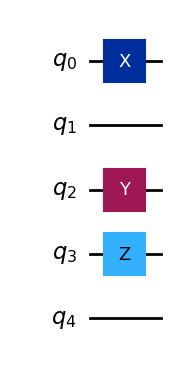

In [21]:
qc_a = QuantumCircuit(5)
qc_a.x(0)

qc_b = QuantumCircuit(3, name="qc_b")
qc_b.y(0)
qc_b.z(1)

# compose qubits (0, 1) of qc_a to qubits (1, 3) of qc_b respectively
combined = qc_a.compose(qc_b, qubits=[2, 3, 4] )
combined.draw("mpl")

In [25]:
gate = qc_b.to_gate()
instr = qc_b.to_instruction()    # If the circuit is unitary
qc = QuantumCircuit(5)
qc.append(gate, [0, 1, 2])
qc.append(instr, [0, 3, 4])

qc.draw()

┌───────┐┌───────┐
q_0: ┤0      ├┤0      ├
     │       ││       │
q_1: ┤1 qc_b ├┤       ├
     │       ││       │
q_2: ┤2      ├┤  qc_b ├
     └───────┘│       │
q_3: ─────────┤1      ├
              │       │
q_4: ─────────┤2      ├
              └───────┘

Decompose the circuit in standard gates

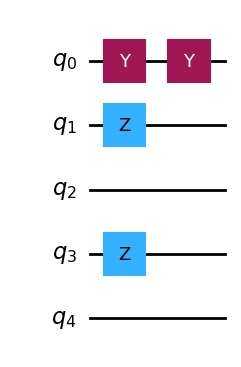

In [26]:
qc.decompose().draw("mpl")

Depth of the circuit: number of gates that can be executed in parallel

In [27]:
qc.depth()

2

Width of the circuit: number of qubits, ancillas and cbits

In [28]:
qc.width()

5

In [29]:
qc.size()

2

Count operations

In [31]:
qc.count_ops()

OrderedDict([('qc_b', 2)])

In [32]:
qc.decompose().count_ops()

OrderedDict([('y', 2), ('z', 2)])

Reset a qubit

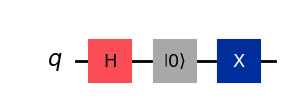

In [30]:
qcr = QuantumCircuit(1)
qcr.h(0)
qcr.reset(0)
qcr.x(0) 
qcr.draw("mpl") # will be measured as 1

Measure qubits
(from the documentation)

- QuantumCircuit.measure : measures each qubit in the first argument onto the classical bit given as the second argument. This method allows full control over where the measurement result is stored.

- QuantumCircuit.measure_all : takes no argument and can be used for quantum circuits without pre-defined classical bits. It creates classical wires and stores measurement results in order. For example, measurement of qubit q is stored in cbit meas). It also adds a barrier before the measurement.

- QuantumCircuit.measure_active : similar to measure_all, but measures only qubits that have operations.

Parametrized circuits

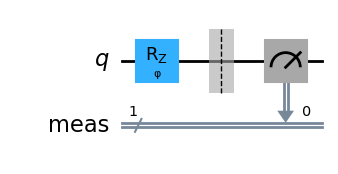

In [36]:
import numpy as np
from qiskit.circuit import Parameter

qc = QuantumCircuit(1)
phi = Parameter("φ")
qc.rz(phi, 0)
qc.measure_all()
qc.draw("mpl")

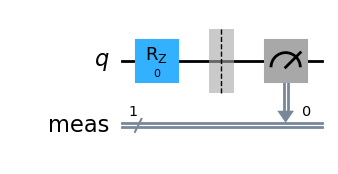

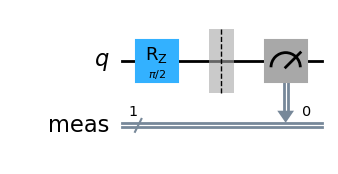

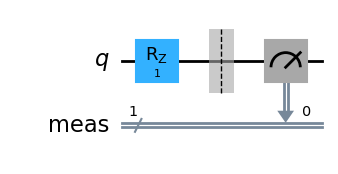

In [53]:
# Sets values:
phi_params = [0, np.pi/2, 1]

# Create circuits to simulate later:
circuits = []
for param in phi_params:
    circuits.append(qc.assign_parameters({phi : param}))
    # Append: we add the circuit in the list

for circuit in circuits:
    display(circuit.draw("mpl"))

In [55]:
qc.parameters

ParameterView([Parameter(φ)])

# Control flows
- if_test & if_else

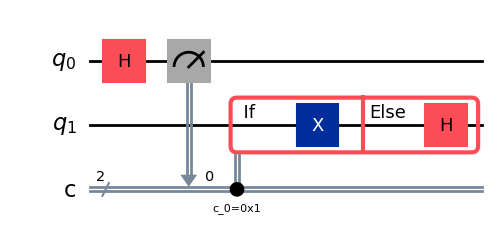

In [58]:
qccf = QuantumCircuit(2,2)

qccf.h(0)
qccf.measure(0, 0)

with qccf.if_test((0, 1)) as else_:    #we (0,1) : we test clbit 0 and apply X if the measurement is 1
    qccf.x(1)
with else_:
    qccf.h(1)
qccf.draw("mpl")

## Others

Random circuit generation

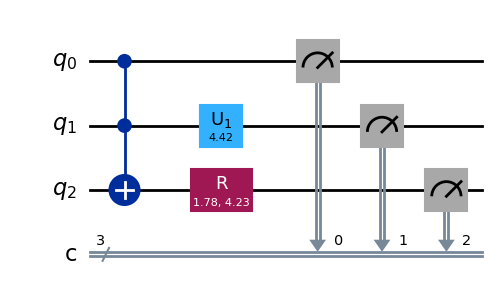

In [9]:
from qiskit.circuit.random import random_circuit

# 3 qubits, Depth=2
qc_random = random_circuit(3, 2, measure=True)
qc_random.draw("mpl")

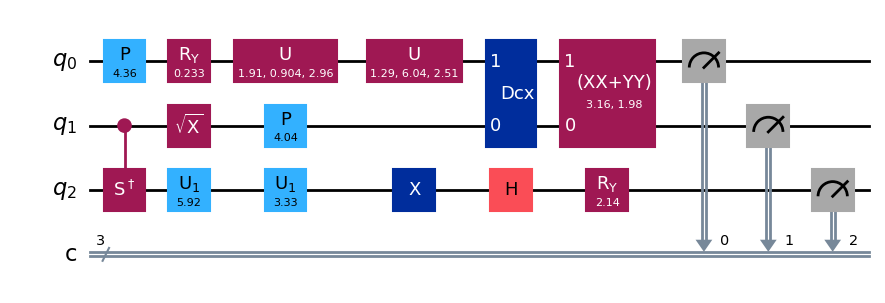

In [11]:
qc_random2 = random_circuit(3, 6, measure=True)
qc_random2.draw("mpl")

Decompose a circuit

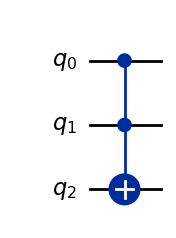

In [14]:
qc_d = QuantumCircuit(3)
qc_d.ccx(0,1,2)
qc_d.draw("mpl")

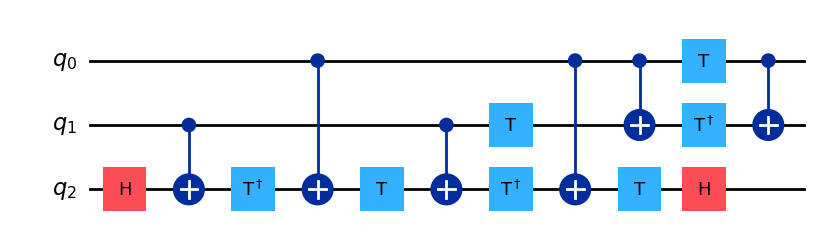

In [16]:
qc_d.decompose().draw("mpl")